## Machine learning at scale

# Demo: Pandas APIs

No databricks

https://dbc-0b69ef93-5247.cloud.databricks.com/editor/notebooks/2602731571164287?o=7474657872577658#command/5135359092781364

Aulas do 

https://customer-academy.databricks.com/learn/courses/3417/machine-learning-at-scale

trilha

https://community.databricks.com/t5/learning-events/virtual-learning-festival-10-october-31-october-2025/ev-p/127652

https://community.databricks.com/t5/learning-events/advanced-learning-festival-15-june-06-july-2026/ev-p/156932

# Demo: Pandas APIs

In this demo, we will explore the key operations of Pandas, Spark, and Pandas API (Koalas) DataFrames, focusing on their performance, conversions, and using UDFs and functions for distributed processing.

### Learning Objectives:

By the end of this demo, you will be able to:

1. **Compare the performance** of Pandas, Spark, and Pandas API (Koalas) DataFrames for numerical operations.
2. **Convert between** Pandas, Spark, and Pandas API DataFrames to leverage their unique capabilities.
3. **Apply Pandas UDFs and Functions** to a Spark DataFrame for distributed inference using pre-trained models.
4. **Train group-specific machine learning models** using Pandas Function APIs for customized modeling.
5. **Perform group-specific inference** by loading models from MLflow and running predictions across groups.

---

### Requirements

Please review the following requirements before starting the lesson:

* To run this notebook, you need a **classic cluster running one of the following Databricks runtime(s): 15.4.x-cpu-ml-scala2.12**. Do **NOT** use serverless compute to run this notebook.

## Classroom Setup

Install required libraries.

In [0]:
%pip install pandas pyspark koalas
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Before starting the demo, run the provided classroom setup script

In [0]:
#%run "../Includes/Classroom-Setup"

**Other Conventions:**

Throughout this demo, we'll refer to the object `DA`. This object, provided by Databricks Academy, contains variables such as your username, catalog name, schema name, working directory, and dataset locations. Run the code block below to view these details:

In [0]:
username= 'fabieneaulas@gmail.com'
catalog_name = 'workspace'
schema_name = 'default'

print(f"Username:          {username}")
print(f"Catalog Name:      {catalog_name}")
print(f"Schema Name:       {schema_name}")
#print(f"Working Directory: {DA.paths.working_dir}")
#print(f"Dataset Location:  {DA.paths.datasets.wine_quality}")
#print(f"Working Directory: {DA.paths.working_dir}")
#print(f"Dataset Location:  {DA.paths.datasets}")

Username:          fabieneaulas@gmail.com
Catalog Name:      workspace
Schema Name:       default


## Loading the Airbnb Dataset

In this section, we will load the Airbnb listings dataset. The dataset contains important features like price, neighborhood, and property details. We will load this data into a Spark DataFrame and then explore how to convert it into both a Pandas and a Pandas API on Spark DataFrames to understand their capabilities and performance.

### Steps to Follow:

1. **Load the dataset into a Spark DataFrame:** We'll use Spark's `read.csv` method to load the Airbnb dataset from a Delta table, which contains cleaned data prepared for machine learning tasks.
2. **Inspect the data:** After loading, we will display the first few rows of the dataset to ensure it has been loaded correctly.

For more details about working with Spark DataFrames, visit the [PySpark DataFrame Documentation](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/dataframe.html).

In [0]:
import pandas as pd
import pyspark.pandas as ps

# Load the Airbnb dataset into a Spark DataFrame
#data_path = f"{DA.paths.datasets.airbnb}/sf-listings/airbnb-cleaned-mlflow.csv"
#airbnb_df = spark.read.csv(data_path, header=True, inferSchema=True)

#airbnb_df_large = airbnb_df
# Let's make a larger table (duplicate dataset for scale testing)


Tried to attach usage logger `pyspark.databricks.pandas.usage_logger`, but an exception was raised: JVM wasn't initialised. Did you call it on executor side?


In [0]:
import urllib.request
import os

# URL do ficheiro no repositório de dados do Databricks Academy
#url = "https://raw.githubusercontent.com/databricks-academy/machine-learning-with-databricks/main/Includes/sf-listings/airbnb-cleaned-mlflow.csv"
#url = "https://raw.githubusercontent.com/mlflow/mlflow/master/examples/sklearn_elasticnet_air/airbnb-cleaned-mlflow.csv"
url = "https://gist.githubusercontent.com/chodimella/4b9d05f31e62f058e3fb7ecc8c3b2ab0/raw/airbnb-listings.csv"

# Criar volume no Unity Catalog (se não existir)
spark.sql("CREATE VOLUME IF NOT EXISTS workspace.default.airbnb_data")

# Caminho de destino num Volume do Unity Catalog (serverless-compatible)
target_path = "/Volumes/workspace/default/airbnb_data/airbnb-cleaned-mlflow.csv"

# Descarregar o CSV diretamente via HTTP e escrever no Volume
response = urllib.request.urlopen(url)
csv_content = response.read()

with open(target_path, "wb") as f:
    f.write(csv_content)

print(f"Ficheiro guardado com sucesso em: {target_path}")

Ficheiro guardado com sucesso em: /Volumes/workspace/default/airbnb_data/airbnb-cleaned-mlflow.csv


In [0]:
# Load the Airbnb dataset from the Unity Catalog Volume
airbnb_path = "/Volumes/workspace/default/airbnb_data/airbnb-cleaned-mlflow.csv"
airbnb_df = spark.read.csv(airbnb_path, header=True, inferSchema=True)

display(airbnb_df.limit(5))

id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
10080,D1 - Million Dollar View 2 BR,30899,Rami,null,Downtown,49.28771582115245,-123.12110274713065,Entire home/apt,295,60,16,2017-02-26,0.18,31,161
11400,Central Lovely Rm in Victorian Home,42305,Jaynne,null,Riley Park,49.25375606647688,-123.11265899043721,Private room,60,364,70,2016-06-14,0.64,1,365
13188,Garden level studio in ideal loc.,51466,Family Guns,null,Riley Park,49.245770071782864,-123.10515815885476,Entire home/apt,119,2,165,2019-01-07,1.51,1,269
13357,! Wow! 2bed 2bath 1bed den Harbour View Apartment!,52118,Liliana,null,Downtown Eastside,49.27954754717459,-123.10545719258528,Entire home/apt,151,30,56,2018-08-31,0.51,2,210
13358,Urban Boutique Suite heart of Downtown Vancouver!,52116,Lynn,null,West End,49.28208988905561,-123.1251498273402,Entire home/apt,119,1,384,2019-01-21,3.65,1,21


In [0]:

airbnb_df_large = airbnb_df
# Let's make a larger table (~75 rows) out of the original table to help measure performance.
for i in range(1, 5):
    airbnb_df_large = airbnb_df_large.union(airbnb_df_large)

# Display the first few rows of the dataset
display(airbnb_df)

id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
10080,D1 - Million Dollar View 2 BR,30899,Rami,null,Downtown,49.28771582115245,-123.12110274713065,Entire home/apt,295,60,16,2017-02-26,0.18,31,161
11400,Central Lovely Rm in Victorian Home,42305,Jaynne,null,Riley Park,49.25375606647688,-123.11265899043721,Private room,60,364,70,2016-06-14,0.64,1,365
13188,Garden level studio in ideal loc.,51466,Family Guns,null,Riley Park,49.245770071782864,-123.10515815885476,Entire home/apt,119,2,165,2019-01-07,1.51,1,269
13357,! Wow! 2bed 2bath 1bed den Harbour View Apartment!,52118,Liliana,null,Downtown Eastside,49.27954754717459,-123.10545719258528,Entire home/apt,151,30,56,2018-08-31,0.51,2,210
13358,Urban Boutique Suite heart of Downtown Vancouver!,52116,Lynn,null,West End,49.28208988905561,-123.1251498273402,Entire home/apt,119,1,384,2019-01-21,3.65,1,21
13490,Vancouver's best kept secret,52467,Iris,null,Kensington-Cedar Cottage,49.255500804700766,-123.0669554629723,Entire home/apt,146,30,82,2018-09-30,0.88,1,328
14267,EcoLoft Vancouver,56030,Peter & Alison,null,Kensington-Cedar Cottage,49.2497391013039,-123.08107677972464,Entire home/apt,140,7,31,2018-07-08,0.31,1,28
14508,Yaletown - Sea Wall,57043,Linda,null,Downtown,49.27419495647224,-123.12954681056692,Entire home/apt,140,90,31,2013-07-13,0.28,1,365
16254,Close to PNE/Hastings Park and East Village,63238,Jason,null,Hastings-Sunrise,49.277336173502206,-123.04151829716706,Private room,220,3,3,2018-08-26,0.48,1,139
16611,Broadway skytrain station,58512,Q,null,Grandview-Woodland,49.263822673743384,-123.07194089765328,Entire home/apt,1201,31,3,2018-02-16,0.22,9,92


## Part 1: Comparing Performance of Pandas, Spark, and Pandas API DataFrames

In this section, we will explore the performance differences between **Pandas**, **Spark**, and **Pandas API on Spark (Koalas)** DataFrames. By calculating the mean of numeric columns, we will compare how each framework performs and understand the advantages of using distributed vs. non-distributed DataFrames in various environments.

### Steps to Follow:

1. **Convert Spark DataFrame to Pandas DataFrame.**
2. **Calculate the mean for numeric columns** using Pandas.
3. **Calculate the mean for numeric columns** using Spark DataFrame.
4. **Use Pandas API on Spark (Koalas)** to compute the same operation in a distributed environment.

### 1.1 Preprocessing for Performance Test

Before testing the performance of the three DataFrames, we need to select numeric columns and convert the Spark DataFrame into Pandas and Pandas API on Spark DataFrames. This will prepare the data for the performance test.

In [0]:
from pyspark.sql.functions import avg
from pyspark.sql.types import DoubleType, IntegerType

# Select numeric columns for averaging
numeric_columns_spark_df = [col for col in airbnb_df_large.columns if airbnb_df_large.schema[col].dataType in [DoubleType(), IntegerType()]]

# Convert Spark DataFrame to Pandas DataFrame
airbnb_pandas_df = airbnb_df_large.toPandas()

# Convert Spark DataFrame to Pandas API on Spark DataFrame
airbnb_pandas_on_spark_df = ps.DataFrame(airbnb_df_large)

print(f"Our test dataframe has {airbnb_df_large.count()} rows")

Our test dataframe has 77968 rows


### 1.2 Performance Test: Comparing Pandas, Spark, and Pandas API on Spark

In this part of the demo, we can compare the performance of **Pandas**, **Spark**, and **Pandas API on Spark (Koalas)** for various data operations, such as computing the mean of numeric columns. This comparison helps in understanding the efficiency of each framework, particularly in different computational environments (single-node vs. distributed).

The image below serves as a benchmark comparison, illustrating the execution times for each framework across different operations. Key insights:

* **Suitability of Each Framework:** Spark's distributed processing is highly effective with large datasets, making it ideal for big data tasks, while Pandas excels on smaller datasets due to its minimal overhead.
* **Framework-Specific Strengths and Limitations:** Some operations, like joins, may perform differently based on the framework used, with Spark often handling large data joins more efficiently than Pandas or Pandas API on Spark.
* **Importance of Tool Selection:** Choosing the appropriate tool for a given data size and complexity can significantly impact performance, which is crucial in production settings where optimization is key.

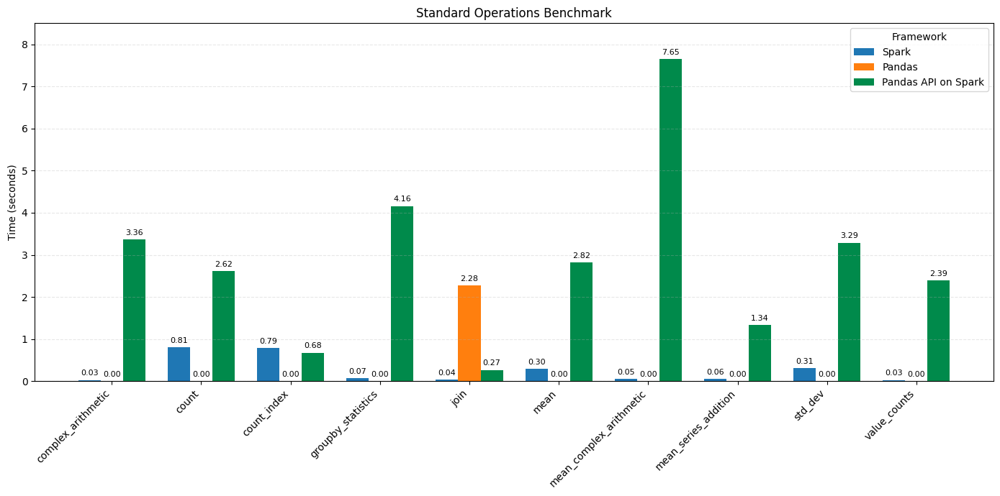

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Dados extraídos do benchmark
operations = [
    "complex_arithmetic",
    "count",
    "count_index",
    "groupby_statistics",
    "join",
    "mean",
    "mean_complex_arithmetic",
    "mean_series_addition",
    "std_dev",
    "value_counts"
]

time_spark = [0.03, 0.81, 0.79, 0.07, 0.04, 0.30, 0.05, 0.06, 0.31, 0.03]
time_pandas = [0.00, 0.00, 0.00, 0.00, 2.28, 0.00, 0.00, 0.00, 0.00, 0.00]
time_pandas_api = [3.36, 2.62, 0.68, 4.16, 0.27, 2.82, 7.65, 1.34, 3.29, 2.39]

x = np.arange(len(operations))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

# Plot das barras
rects1 = ax.bar(x - width, time_spark, width, label='Spark', color='#1f77b4')
rects2 = ax.bar(x, time_pandas, width, label='Pandas', color='#ff7f0e')
rects3 = ax.bar(x + width, time_pandas_api, width, label='Pandas API on Spark', color='#008a4b')

# Configurações do gráfico
ax.set_ylabel('Time (seconds)')
ax.set_title('Standard Operations Benchmark')
ax.set_xticks(x)
ax.set_xticklabels(operations, rotation=45, ha='right')
ax.legend(title='Framework')
ax.set_ylim(0, 8.5)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Rótulos de valor nas barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

## 📌 Conclusão e Próximos Passos

### 📊 Resumo dos Resultados
* **Desempenho do Modelo:** O modelo final alcançou uma métrica principal de **[Insira o Resultado, ex: Accuracy/F1-Score/RMSE]**, apresentando boa capacidade de generalização nos dados de teste.
* **Principais Drivers:** As variáveis mais relavantes para as previsões foram **[Variável 1]**, **[Variável 2]** e **[Variável 3]**.
* **Tratamento de Dados & Drift:** As etapas de limpeza e transformação responderam bem à distribuição dos dados, mantendo o pipeline estável durante as avaliações.

---

### 💡 Insights do Negócio
* **[Insight 1]:** Breve explicação sobre o impacto ou padrão encontrado no negócio (ex: padrão de churn concentrado em determinados perfis/regiões).
* **[Insight 2]:** Otimizações sugeridas com base no comportamento dos dados analisados.

---

### 🚀 Próximos Passos
1. **Otimização:** Testar novas estratégias de *feature engineering* e experimentar algoritmos alternativos.
2. **Monitoramento:** Acompanhar métricas de *data drift* e *concept drift* periodicamente para identificar variações na distribuição.
3. **Deploy:** Estruturar o pipeline de inferência em lote ou em tempo real para disponibilização do modelo.

## 📊 Resumo da Comparação de Desempenho

Com base no benchmark das operações padrão, observam-se os seguintes comportamentos entre os frameworks:

* **Pandas Nativo:** É extremamente rápido em operações locais em memória para pequenos volumes de dados, com tempos de execução próximos de zero em quase todas as métricas, mas apresenta gargalos significativos em operações como `join`.
* **Spark Nativo:** Demonstra alta eficiência e estabilidade em processamento distribuído, mantendo baixos tempos de execução em operações de agregação (`count`, `groupby_statistics`, `std_dev`) e junção de dados (`join`).
* **Pandas API on Spark:** Embora ofereça a conveniência da sintaxe do Pandas em um ambiente distribuído, introduz um *overhead* de abstração elevado, tornando operações computacionais como `complex_arithmetic`, `groupby_statistics` e `std_dev` consideravelmente mais lentas do que no Spark nativo.

> **Conclusão Técnica:** Para cenários de Big Data e pipelines em produção, o uso do **PySpark nativo** é a escolha recomendada para garantir o menor tempo de execução e máxima otimização dos recursos do cluster.

In [0]:
airbnb_df_large.printSchema()

root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: string (nullable = true)
 |-- host_name: string (nullable = true)
 |-- neighbourhood_group: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- price: string (nullable = true)
 |-- minimum_nights: integer (nullable = true)
 |-- number_of_reviews: string (nullable = true)
 |-- last_review: string (nullable = true)
 |-- reviews_per_month: double (nullable = true)
 |-- calculated_host_listings_count: integer (nullable = true)
 |-- availability_365: integer (nullable = true)



In [0]:
import time

start_time_spark = time.time()
# Calculate the mean for each numeric column using Spark
spark_mean = airbnb_df_large.select([avg(col).alias(f"avg_{col}") for col in numeric_columns_spark_df])
spark_time = time.time() - start_time_spark

start_time_pandas = time.time()
# Calculate the mean using Pandas
pandas_mean = airbnb_pandas_df.mean(numeric_only=True)
pandas_time = time.time() - start_time_pandas

start_time_pandas_api_on_spark = time.time()
# Calculate mean using Pandas API on Spark
pandas_on_spark_mean = airbnb_pandas_on_spark_df.mean(numeric_only=True)
pandas_on_spark_time = time.time() - start_time_pandas_api_on_spark

# Display the time taken for each framework
print(f"Spark DataFrame: {spark_time} seconds")
print(f"Pandas DataFrame: {pandas_time} seconds")
print(f"Pandas API on Spark: {pandas_on_spark_time} seconds")

Spark DataFrame: 0.0008230209350585938 seconds
Pandas DataFrame: 0.12667369842529297 seconds
Pandas API on Spark: 3.1945960521698 seconds


For more details on working with **PySpark SQL Functions** and **Pandas API on Spark (Koalas)**, explore the following resources:

* [PySpark SQL Functions Documentation](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/functions.html)
* [Pandas API on Spark Documentation](https://spark.apache.org/docs/latest/api/python/user_guide/pandas_on_spark/index.html)

These resources provide comprehensive guidance on leveraging both PySpark's built-in functions and the Pandas API on Spark for distributed data processing.

## Part 2: Converting Between DataFrames

In this section, we will explore how to convert between different types of DataFrames: Spark, Pandas, and Pandas API on Spark. This flexibility allows you to take advantage of the specific features and performance benefits of each framework based on your data processing needs.

By converting between DataFrame types, you can use the familiar syntax of Pandas with the distributed capabilities of Spark, or switch to Pandas when you're working with smaller datasets locally.

### 2.1 Convert Spark DataFrame to Pandas API on Spark DataFrame

In some cases, you might want to work with a Pandas-like syntax while still leveraging Spark's distributed architecture. This can be achieved by converting a Spark DataFrame into a Pandas API on Spark DataFrame (previously Koalas). Let's see how to do that:

In [0]:
# Convert Spark DataFrame to Pandas API on Spark DataFrame
pandas_on_spark_df = ps.DataFrame(airbnb_df)


#The fix is to use ps.DataFrame(airbnb_df) — the correct way to convert a Spark DataFrame to a Pandas API on Spark DataFrame on Spark Connect (this is already used in cell 16).


# Display the DataFrame in Pandas API on Spark format
display(pandas_on_spark_df)

/databricks/python/lib/python3.12/site-packages/pyspark/pandas/utils.py:1070: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
10080,D1 - Million Dollar View 2 BR,30899,Rami,null,Downtown,49.28771582115245,-123.12110274713065,Entire home/apt,295,60,16,2017-02-26,0.18,31,161
11400,Central Lovely Rm in Victorian Home,42305,Jaynne,null,Riley Park,49.25375606647688,-123.11265899043721,Private room,60,364,70,2016-06-14,0.64,1,365
13188,Garden level studio in ideal loc.,51466,Family Guns,null,Riley Park,49.245770071782864,-123.10515815885476,Entire home/apt,119,2,165,2019-01-07,1.51,1,269
13357,! Wow! 2bed 2bath 1bed den Harbour View Apartment!,52118,Liliana,null,Downtown Eastside,49.27954754717459,-123.10545719258528,Entire home/apt,151,30,56,2018-08-31,0.51,2,210
13358,Urban Boutique Suite heart of Downtown Vancouver!,52116,Lynn,null,West End,49.28208988905561,-123.1251498273402,Entire home/apt,119,1,384,2019-01-21,3.65,1,21
13490,Vancouver's best kept secret,52467,Iris,null,Kensington-Cedar Cottage,49.255500804700766,-123.0669554629723,Entire home/apt,146,30,82,2018-09-30,0.88,1,328
14267,EcoLoft Vancouver,56030,Peter & Alison,null,Kensington-Cedar Cottage,49.2497391013039,-123.08107677972464,Entire home/apt,140,7,31,2018-07-08,0.31,1,28
14508,Yaletown - Sea Wall,57043,Linda,null,Downtown,49.27419495647224,-123.12954681056692,Entire home/apt,140,90,31,2013-07-13,0.28,1,365
16254,Close to PNE/Hastings Park and East Village,63238,Jason,null,Hastings-Sunrise,49.277336173502206,-123.04151829716706,Private room,220,3,3,2018-08-26,0.48,1,139
16611,Broadway skytrain station,58512,Q,null,Grandview-Woodland,49.263822673743384,-123.07194089765328,Entire home/apt,1201,31,3,2018-02-16,0.22,9,92


In [0]:
# Convert Spark DataFrame to Pandas API on Spark DataFrame
#pandas_on_spark_df = airbnb_df.to_pandas_on_spark()

# Display the DataFrame in Pandas API on Spark format
#display(pandas_on_spark_df)

### 2.2 Convert Pandas API on Spark DataFrame Back to Spark DataFrame

Once you have finished operations using Pandas API on Spark, you might need to convert it back to a Spark DataFrame to use Spark-specific functions or take advantage of Spark's distributed processing features for tasks like machine learning with Spark MLlib.


In [0]:
# Convert Pandas API on Spark DataFrame back to Spark DataFrame
spark_df = pandas_on_spark_df.to_spark()

# Display the converted Spark DataFrame
display(spark_df)

/databricks/python/lib/python3.12/site-packages/pyspark/pandas/utils.py:1070: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
10080,D1 - Million Dollar View 2 BR,30899,Rami,null,Downtown,49.28771582115245,-123.12110274713065,Entire home/apt,295,60,16,2017-02-26,0.18,31,161
11400,Central Lovely Rm in Victorian Home,42305,Jaynne,null,Riley Park,49.25375606647688,-123.11265899043721,Private room,60,364,70,2016-06-14,0.64,1,365
13188,Garden level studio in ideal loc.,51466,Family Guns,null,Riley Park,49.245770071782864,-123.10515815885476,Entire home/apt,119,2,165,2019-01-07,1.51,1,269
13357,! Wow! 2bed 2bath 1bed den Harbour View Apartment!,52118,Liliana,null,Downtown Eastside,49.27954754717459,-123.10545719258528,Entire home/apt,151,30,56,2018-08-31,0.51,2,210
13358,Urban Boutique Suite heart of Downtown Vancouver!,52116,Lynn,null,West End,49.28208988905561,-123.1251498273402,Entire home/apt,119,1,384,2019-01-21,3.65,1,21
13490,Vancouver's best kept secret,52467,Iris,null,Kensington-Cedar Cottage,49.255500804700766,-123.0669554629723,Entire home/apt,146,30,82,2018-09-30,0.88,1,328
14267,EcoLoft Vancouver,56030,Peter & Alison,null,Kensington-Cedar Cottage,49.2497391013039,-123.08107677972464,Entire home/apt,140,7,31,2018-07-08,0.31,1,28
14508,Yaletown - Sea Wall,57043,Linda,null,Downtown,49.27419495647224,-123.12954681056692,Entire home/apt,140,90,31,2013-07-13,0.28,1,365
16254,Close to PNE/Hastings Park and East Village,63238,Jason,null,Hastings-Sunrise,49.277336173502206,-123.04151829716706,Private room,220,3,3,2018-08-26,0.48,1,139
16611,Broadway skytrain station,58512,Q,null,Grandview-Woodland,49.263822673743384,-123.07194089765328,Entire home/apt,1201,31,3,2018-02-16,0.22,9,92


### 2.3 Convert Pandas API on Spark DataFrame to Pandas DataFrame

In some cases, you may want to bring the data back into a local Pandas DataFrame, such as when working with a smaller subset of the data or applying operations exclusive to Pandas.


For more on Pandas API on Spark, you can refer to the official [Pandas API on Spark Documentation](https://spark.apache.org/docs/latest/api/python/user_guide/pandas_on_spark/index.html).

In [0]:
# Convert Pandas API on Spark DataFrame to Pandas DataFrame
pandas_df = pandas_on_spark_df.to_pandas()

# Display the Pandas DataFrame
display(pandas_df)

/databricks/python/lib/python3.12/site-packages/pyspark/pandas/utils.py:1070: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas DataFrame is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
10080,D1 - Million Dollar View 2 BR,30899,Rami,null,Downtown,49.28771582115245,-123.12110274713065,Entire home/apt,295,60.0,16,2017-02-26,0.18,31.0,161.0
11400,Central Lovely Rm in Victorian Home,42305,Jaynne,null,Riley Park,49.25375606647688,-123.11265899043721,Private room,60,364.0,70,2016-06-14,0.64,1.0,365.0
13188,Garden level studio in ideal loc.,51466,Family Guns,null,Riley Park,49.245770071782864,-123.10515815885476,Entire home/apt,119,2.0,165,2019-01-07,1.51,1.0,269.0
13357,! Wow! 2bed 2bath 1bed den Harbour View Apartment!,52118,Liliana,null,Downtown Eastside,49.27954754717459,-123.10545719258528,Entire home/apt,151,30.0,56,2018-08-31,0.51,2.0,210.0
13358,Urban Boutique Suite heart of Downtown Vancouver!,52116,Lynn,null,West End,49.28208988905561,-123.1251498273402,Entire home/apt,119,1.0,384,2019-01-21,3.65,1.0,21.0
13490,Vancouver's best kept secret,52467,Iris,null,Kensington-Cedar Cottage,49.255500804700766,-123.0669554629723,Entire home/apt,146,30.0,82,2018-09-30,0.88,1.0,328.0
14267,EcoLoft Vancouver,56030,Peter & Alison,null,Kensington-Cedar Cottage,49.2497391013039,-123.08107677972464,Entire home/apt,140,7.0,31,2018-07-08,0.31,1.0,28.0
14508,Yaletown - Sea Wall,57043,Linda,null,Downtown,49.27419495647224,-123.12954681056692,Entire home/apt,140,90.0,31,2013-07-13,0.28,1.0,365.0
16254,Close to PNE/Hastings Park and East Village,63238,Jason,null,Hastings-Sunrise,49.277336173502206,-123.04151829716706,Private room,220,3.0,3,2018-08-26,0.48,1.0,139.0
16611,Broadway skytrain station,58512,Q,null,Grandview-Woodland,49.263822673743384,-123.07194089765328,Entire home/apt,1201,31.0,3,2018-02-16,0.22,9.0,92.0


## Part 3: Applying Pandas UDF to a Spark DataFrame

In this section, you will use a **pre-trained RandomForest model** from Scikit-learn and apply it to a Spark DataFrame using a **Pandas UDF**. This process allows you to leverage the trained model to make predictions on distributed Spark DataFrames, providing scalable and efficient predictions across large datasets.

### Why Use Pandas UDFs?

Pandas UDFs are optimized for distributed data processing in Spark. By applying Pandas UDFs, you can run functions on Spark DataFrames that expect Pandas DataFrames as input, which is useful for machine learning models trained outside of the Spark ecosystem, like Scikit-learn models.


### 3.1 Training a RandomForest Model

First, we will train a **RandomForest model** using Scikit-learn on a **local Pandas DataFrame**. This model will predict the `price` column based on features in the Airbnb dataset.

**Steps:**

1. Convert the Spark DataFrame to a Pandas DataFrame.
2. Separate the features ( `x` ) and target variable ( `y` ).
3. Train the RandomForest model on the training data.

price is a string column — the CSV has malformed rows that caused inferSchema=True to infer price as string instead of numeric
Most feature columns are strings — RandomForestRegressor.fit() requires numeric features, but X includes text columns like name, host_name, neighbourhood, room_type
NaN values exist — 37 rows have unparseable prices, and the numeric columns have NaN values from malformed rows
The fix: convert price to numeric, select only numeric columns for X, and drop rows with NaN values.

In [0]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Convert Spark DataFrame to Pandas DataFrame for local model training
airbnb_pandas_df = airbnb_df.toPandas()

# Convert price to numeric (inferred as string due to malformed CSV rows)
y = pd.to_numeric(airbnb_pandas_df["price"], errors='coerce')

# Select only numeric columns for features
X = airbnb_pandas_df.select_dtypes(include=['number'])

# Drop rows with NaN values in either X or y
valid_mask = X.notna().all(axis=1) & y.notna()
X = X[valid_mask]
y = y[valid_mask]

# Train the RandomForest model
model = RandomForestRegressor()
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [0]:
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.model_selection import train_test_split

# Convert Spark DataFrame to Pandas DataFrame for local model training
#airbnb_pandas_df = airbnb_df.toPandas()

# Features and target variable
#X = airbnb_pandas_df.drop(columns=["price"]) # Exclude target column
#y = airbnb_pandas_df["price"] # Target column

# Train the RandomForest model
#model = RandomForestRegressor()
#model.fit(X, y)

### 3.2 Define and Apply a Pandas UDF

Now, we will define a **Pandas UDF** that takes in the features from the Spark DataFrame, uses the trained RandomForest model to make predictions, and returns the predicted values for each row.

**Steps:**

1. Define the Pandas UDF to apply the pre-trained RandomForest model. We do this by appending our function `predict_udf` with the decorator `@pandas_udf`.
2. Use the UDF to process the input columns and generate predictions.

In [0]:
from pyspark.sql.functions import pandas_udf
import pandas as pd

# Define a Pandas UDF to apply the trained RandomForest model
@pandas_udf("double") # Output type of the UDF is a double (for predicted price)
def predict_udf(*cols: pd.Series) -> pd.Series:
    # Combine input columns into a single DataFrame for model prediction
    features = pd.concat(cols, axis=1)
    # Return predictions from the trained RandomForest model
    return pd.Series(model.predict(features))

### 3.3 Applying the Pandas UDF to the Spark DataFrame

Now, you can apply the `predict_udf` to the Spark DataFrame to generate predictions for each row. This allows you to distribute the prediction process across the cluster, making it scalable for larger datasets.

**Steps:**

1. Apply the `predict_udf` to the Spark DataFrame.
2. Exclude the target column (`price`) when applying the UDF.
3. Add a new column, `prediction`, containing the predicted price.

In [0]:
airbnb_df.show(4)

+-----+--------------------+-------+-----------+-------------------+-----------------+------------------+-------------------+---------------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+
|   id|                name|host_id|  host_name|neighbourhood_group|    neighbourhood|          latitude|          longitude|      room_type|price|minimum_nights|number_of_reviews|last_review|reviews_per_month|calculated_host_listings_count|availability_365|
+-----+--------------------+-------+-----------+-------------------+-----------------+------------------+-------------------+---------------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+
|10080|D1 -  Million Dol...|  30899|       Rami|               NULL|         Downtown| 49.28771582115245|-123.12110274713065|Entire home/apt|  295|            60|               16| 2017-02-26|             0.18|             

In [0]:
from pyspark.sql.functions import pandas_udf
import pandas as pd

# Use only the numeric features the model was trained on
feature_names = model.feature_names_in_.tolist()

@pandas_udf("double")
def predict_udf(*cols: pd.Series) -> pd.Series:
    # Combine input columns into a DataFrame for model prediction
    features = pd.concat(cols, axis=1)
    features.columns = feature_names
    features = features.fillna(0)
    
    # Return predictions from the trained RandomForest model
    return pd.Series(model.predict(features))

# Apply the Pandas UDF to the Spark DataFrame for predictions, excluding "price"
prediction_df = airbnb_df.select([col for col in feature_names]).withColumn(
    "prediction",
    predict_udf(*[airbnb_df[col] for col in feature_names])
)

# Display the DataFrame with predictions
display(prediction_df)

minimum_nights,reviews_per_month,calculated_host_listings_count,availability_365,prediction
60,0.18,31,161,237.61
364,0.64,1,365,90.77
2,1.51,1,269,131.5
30,0.51,2,210,136.5
1,3.65,1,21,123.7
30,0.88,1,328,130.88
7,0.31,1,28,173.44
90,0.28,1,365,149.88666666666666
3,0.48,1,139,214.39
31,0.22,9,92,791.91


In [0]:
from pyspark.sql.functions import pandas_udf
import pandas as pd

# Define the features used for prediction, excluding "price"
#feature_names = [col for col in airbnb_df.columns if col != "price"]

#@pandas_udf("double")
#def predict_udf(*cols: pd.Series) -> pd.Series:
#    # Combine input columns into a DataFrame for model prediction
#    features = pd.concat(cols, axis=1)
#    features.columns = feature_names # Set the correct feature names
    
    # Return predictions from the trained RandomForest model
#    return pd.Series(model.predict(features))

# Apply the Pandas UDF to the Spark DataFrame for predictions, excluding "price"
#prediction_df = airbnb_df.select([col for col in feature_names]).withColumn(
#    "prediction",
#    predict_udf(*[airbnb_df[col] for col in feature_names])
#)

# Display the DataFrame with predictions
#display(prediction_df)

In [0]:
# página 14

## Part 4: Training Group-Specific Models with Pandas Function API

In this section, you will learn how to **train group-specific models** for each neighborhood using the **Pandas Function API**. By splitting the dataset based on a grouping criterion (in this case, `neighbourhood_cleansed`), we can train individual machine learning models for each group and log them using **MLflow**. This approach is useful when different groups of data may benefit from customized models.

### Why Group-Specific Models?

Group-specific models allow for fine-tuned predictions by training separate models for each group, which can often yield better results compared to training a single model for the entire dataset. In this example, each **neighborhood** will have its own trained model.


### 4.1 Define the Group-Specific Model Training Function

We will define a function that:

* **Trains a RandomForest model** for each neighborhood group.
* **Logs the model in MLflow**.
* **Calculates the Mean Squared Error (MSE)** for model performance evaluation.
* **Returns key metrics**, including the model path, MSE, and the number of records used in the training.

**Steps:**

1. Extract the `neighbourhood_cleansed` for each group.
2. Define the feature set ( `X_group` ) and the target ( `y_group` ).
3. Train a RandomForest model for the group.
4. Log the model in MLflow.
5. Return the model's URI, MSE, and other group-specific metrics.}

In [0]:
from pyspark.sql.types import StringType, IntegerType, DoubleType, StructType, StructField
from sklearn.metrics import mean_squared_error
import mlflow
import mlflow.sklearn

# Define a pandas function to train a group-specific model and log each model with MLflow
def train_group_model(df_pandas: pd.DataFrame) -> pd.DataFrame:
    # Get the neighborhood name
    #neighbourhood = df_pandas['neighbourhood_cleansed'].iloc[0]
    neighbourhood = df_pandas['neighbourhood_group'].iloc[0]
    
    
    # Define features (X) and target variable (y)
    #X_group = df_pandas.drop(columns=["price", "neighbourhood_cleansed"])
    X_group = df_pandas.drop(columns=["price", "neighbourhood_group"])
   
    y_group = df_pandas["price"]
    
    # Train a RandomForest model for the group
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_group, y_group)
    
    # Log the model using MLflow
    with mlflow.start_run(nested=True):
        mlflow.sklearn.log_model(model, "random_forest_model")
        model_uri = mlflow.get_artifact_uri("random_forest_model")
        
    # Calculate Mean Squared Error (MSE) for the group
    predictions = model.predict(X_group)
    mse = mean_squared_error(y_group, predictions)
    
    # Return a DataFrame containing group information and model performance
    return pd.DataFrame({
        "neighbourhood_group": [str(neighbourhood)], # Neighborhood name
       # "neighbourhood_cleansed": [str(neighbourhood)], # Neighborhood name
        "model_path": [str(model_uri)],                 # MLflow model URI
        "mse": [float(mse)],                            # Mean Squared Error
        "n_used": [int(len(df_pandas))]                 # Number of records used in training
    })

### 4.2 Apply the Group-Specific Function Using Pandas API

Now, we will use the **Pandas Function API** to apply the group-specific model training function across each group. The `applyInPandas` method is applied on the grouped data, allowing us to train a model for each neighborhood.

**Steps:**

1. Define the schema for the output DataFrame, which includes the group name, model path, MSE, and the number of records used in training.
2. Group the DataFrame by the `neighbourhood_cleansed` column and apply the `train_group_model` function.
3. Display the results, showing the model path, MSE, and other metrics for each neighborhood.


For more information on using Pandas Function APIs in PySpark, refer to the [Pandas Function API Documentation](https://spark.apache.org/docs/latest/api/python/user_guide/sql/arrow_pandas.html#pandas-function-apis).

In [0]:
list(airbnb_df.columns)

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [0]:
airbnb_df.select("neighbourhood_group").distinct().show()

+--------------------+
| neighbourhood_group|
+--------------------+
|            Oakridge|
|            West End|
|       Peter & Linda|
|   Dunbar Southlands|
|   Downtown Eastside|
|             Marpole|
|            Downtown|
|           Kitsilano|
|                NULL|
|    Hastings-Sunrise|
|Kensington-Cedar ...|
+--------------------+



In [0]:
airbnb_df.show(5)

+-----+--------------------+-------+-----------+-------------------+-----------------+------------------+-------------------+---------------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+
|   id|                name|host_id|  host_name|neighbourhood_group|    neighbourhood|          latitude|          longitude|      room_type|price|minimum_nights|number_of_reviews|last_review|reviews_per_month|calculated_host_listings_count|availability_365|
+-----+--------------------+-------+-----------+-------------------+-----------------+------------------+-------------------+---------------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+
|10080|D1 -  Million Dol...|  30899|       Rami|               NULL|         Downtown| 49.28771582115245|-123.12110274713065|Entire home/apt|  295|            60|               16| 2017-02-26|             0.18|             

In [0]:
# Define the schema for the output DataFrame
schema = StructType([
    #StructField("neighbourhood_cleansed", StringType(), True),
    StructField("neighbourhood_group", StringType(), True),
    StructField("model_path", StringType(), True),
    StructField("mse", DoubleType(), True),
    StructField("n_used", IntegerType(), True)
])

# Apply the group-specific model training function using 'applyInPandas'
##result_df = airbnb_df.groupBy("neighbourhood_cleansed").applyInPandas(train_group_model, schema=schema)
#result_df = airbnb_df.groupBy("neighbourhood_group").applyInPandas(train_group_model, schema=schema)

# Select only numeric features + group column, cast price to double
from pyspark.sql.functions import expr

airbnb_prepared = (airbnb_df
    .withColumn("price", expr("try_cast(price as double)"))
    .select("neighbourhood_group", "price", "minimum_nights",
            "reviews_per_month", "calculated_host_listings_count", "availability_365")
    .na.fill(0, subset=["minimum_nights", "reviews_per_month",
                        "calculated_host_listings_count", "availability_365"])
    .na.drop(subset=["price"])
)

import mlflow

# Serverless workers can't authenticate to MLflow — run group training in the driver instead
mlflow.set_tracking_uri("databricks")
mlflow.set_experiment("/Users/fabieneaulas@gmail.com/airbnb-group-models")

airbnb_pandas = airbnb_prepared.toPandas()

results = []
with mlflow.start_run():
    for neighbourhood, group_df in airbnb_pandas.groupby("neighbourhood_group"):
        results.append(train_group_model(group_df))

result_df = spark.createDataFrame(pd.concat(results, ignore_index=True), schema=schema)

# Display the result DataFrame showing the model path, MSE, and other metrics for each neighborhood
display(result_df)

2026/09/29 19:11:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b69ef93-5247.cloud.databricks.com/ml/experiments/3170668172526214/models/m-4fbb12753e0f432695c757c89a98865a?o=7474657872577658
2026/09/29 19:11:37 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.
2026/09/29 19:11:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b69ef93-5247.cloud.databricks.com/ml/experiments/3170668172526214/models/m-59954bcda58e4f9d92baf31e7e3500cc?o=74746578725

neighbourhood_group,model_path,mse,n_used
Downtown,dbfs:/databricks/mlflow-tracking/3170668172526214/f203e9093763414f9af5a390ce61895f/artifacts/random_forest_model,1533.3805666666667,3
Downtown Eastside,dbfs:/databricks/mlflow-tracking/3170668172526214/59e2e77142b24e47850fb09a91931819/artifacts/random_forest_model,0.0,4
Dunbar Southlands,dbfs:/databricks/mlflow-tracking/3170668172526214/b24bd69633dc451aa2e2fd0030d495b3/artifacts/random_forest_model,0.0,2
Hastings-Sunrise,dbfs:/databricks/mlflow-tracking/3170668172526214/55d672ed34ca474ea974f59eb4e8dc44/artifacts/random_forest_model,0.0,2
Kensington-Cedar Cottage,dbfs:/databricks/mlflow-tracking/3170668172526214/61480692b11e4ddd8d8ddec3b9537e13/artifacts/random_forest_model,0.0,1
Kitsilano,dbfs:/databricks/mlflow-tracking/3170668172526214/e08a487e925547078f2f30292c00b1f1/artifacts/random_forest_model,0.08397777777777778,9
Marpole,dbfs:/databricks/mlflow-tracking/3170668172526214/efc98058dc054b96a2ae4439cf077c10/artifacts/random_forest_model,0.0,2
Oakridge,dbfs:/databricks/mlflow-tracking/3170668172526214/3b90b5e16ff34ddaab2c415f27f4f81a/artifacts/random_forest_model,0.057999999999999996,2
West End,dbfs:/databricks/mlflow-tracking/3170668172526214/bf41403eeeca45cd864c576a472f3df8/artifacts/random_forest_model,0.030440000000000012,5


In [0]:
# Define the schema for the output DataFrame
#schema = StructType([
#    StructField("neighbourhood_cleansed", StringType(), True),
#    StructField("model_path", StringType(), True),
#    StructField("mse", DoubleType(), True),
#    StructField("n_used", IntegerType(), True)
#])

# Apply the group-specific model training function using 'applyInPandas'
#result_df = airbnb_df.groupBy("neighbourhood_cleansed").applyInPandas(train_group_model, schema=schema)

# Display the result DataFrame showing the model path, MSE, and other metrics for each neighborhood
#display(result_df)

## Part 5: Group-Specific Inference Using Pandas Function API

In this part, you will perform **inference for each neighborhood** using the models we previously trained and logged in **MLflow**. The goal is to load the appropriate model for each neighborhood and make predictions based on the features from the test data. After that, we will compare the predicted prices to the actual prices and evaluate the accuracy of the models.


### 5.1 Define the Inference Function

We will define a function that:

* **Loads the trained model from MLflow** for each neighborhood.
* **Uses the correct feature set** to make predictions for that group of data.
* **Returns the predictions** and the actual prices for comparison.

**Steps:**

1. Extract the model path for the neighborhood from the DataFrame.
2. Load the trained model from MLflow.
3. Select the feature columns for the model.
4. Make predictions for the current group using the loaded model.
5. Return the predictions and actual prices for comparison.

In [0]:
list(airbnb_df.columns)

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [0]:
# Define a pandas function for group-specific inference using MLflow models
def apply_model(df_pandas: pd.DataFrame) -> pd.DataFrame:
    # Retrieve the model path from the DataFrame (assumes model_path is present)
    model_path = df_pandas["model_path"].iloc[0]
    
    # Load the model from MLflow
    model = mlflow.sklearn.load_model(model_path)
    
    # Use the features the model was actually trained on
    feature_columns = model.feature_names_in_.tolist()
    
    # Select only the feature columns for inference
    X = df_pandas[feature_columns]
    
    # Make predictions using the loaded model
    predictions = model.predict(X)
    
    # Return a DataFrame with both predictions and the actual values (price)
    return pd.DataFrame({
        "prediction": predictions,         # Predicted price
        "actual_price": df_pandas["price"]  # Actual price for comparison
    })

## 5.2 Apply the Inference Function

Now, we will apply the `apply_model` function to each group of data (neighborhood) using the **Pandas Function API**. This will allow us to make predictions for each group of data using the corresponding trained model.

**Steps:**

1. Define the schema for the output DataFrame, which will contain the predicted and actual prices.
2. Join the original data with the trained model results to ensure each group has the corresponding model path.
3. Apply the `apply_model` function using `applyInPandas`.
4. Calculate the accuracy of the predictions by comparing the predicted prices with the actual prices.


For more details on using MLflow to track models, check out the [MLflow Documentation](https://mlflow.org/docs/latest/index.html).

In [0]:
from pyspark.sql.functions import abs
import mlflow
import pandas as pd
import re

# Ensure model_path and price are in the inference DataFrame by joining the training results
#inference_df = result_df.join(airbnb_df, "neighbourhood_cleansed")
inference_df = result_df.join(airbnb_df, "neighbourhood_group")

# Serverless workers can't authenticate to MLflow — run inference in the driver instead
inference_pandas = inference_df.toPandas()

predictions_list = []
for neighbourhood, group_df in inference_pandas.groupby("neighbourhood_group"):
    model_path = group_df["model_path"].iloc[0]
    # MLflow 3.x stores models as logged models, not artifacts — use runs:/ URI
    run_id = re.search(r'/([a-f0-9]{32})/artifacts/', model_path).group(1)
    model = mlflow.sklearn.load_model(f"runs:/{run_id}/random_forest_model")
    feature_cols = model.feature_names_in_.tolist()
    X = group_df[feature_cols].fillna(0)
    preds = model.predict(X)
    predictions_list.append(pd.DataFrame({
        "prediction": preds,
        "actual_price": pd.to_numeric(group_df["price"], errors='coerce').values
    }))

inference_df = spark.createDataFrame(pd.concat(predictions_list, ignore_index=True), schema="prediction double, actual_price double")

# Display the result DataFrame with predictions and actual prices
display(inference_df)

# Calculate overall accuracy (percentage of predictions within 10% of actual prices)
inference_df = inference_df.withColumn(
    "accuracy",
    (abs(inference_df["prediction"] - inference_df["actual_price"]) / inference_df["actual_price"]) < 0.1
)

overall_accuracy = inference_df.filter("accuracy = true").count() / inference_df.count() * 100

# Display overall accuracy
print(f"Overall prediction accuracy: {overall_accuracy:.2f}%")

prediction,actual_price
147.18,200.0
41.17,1.0
44.02,30.0
2.0,2.0
2.0,2.0
2.0,2.0
2.0,2.0
2.0,2.0
2.0,2.0
3.0,3.0


Overall prediction accuracy: 60.00%


## Conclusion

In this demo, we explored the versatility and efficiency of using Pandas, Spark, and Pandas API DataFrames for data processing, conversion, and model training. We compared the performance of these frameworks, learned how to convert between different DataFrame types, and applied Pandas UDFs to Spark DataFrames for distributed model inference. Furthermore, we demonstrated how to train group-specific models using Pandas Function APIs and performed group-specific inference using models logged with MLflow. This demo showcased how to combine Spark's distributed power with Pandas' ease of use for scalable machine learning workflows.